In [2]:
#importing all the important libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import random
from torchvision import models, transforms, datasets
import time
import copy

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Since i have a nvidia gpu so i am using cuda
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available, using CPU")
    

NUM_WORKERS  = 12


Using CUDA: NVIDIA GeForce RTX 4060


In [ ]:
class BinaryDataset(Dataset):
    def __init__(self, image_folder_dataset):
        self.dataset = image_folder_dataset
        self.original_classes = image_folder_dataset.classes
        self.label_map = {
            i: (1 if "healthy" in cls.lower() else 0)
            for i, cls in enumerate(self.original_classes)
        }
        self.classes = ["Diseased", "Healthy"]
        self.num_classes = len(self.classes)
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        binary_label = self.label_map[label]
        return image, binary_label


In [ ]:
# since we are going to use mobilenetv3 we need to resize the images and normalize it
mean= [0.485, 0.456, 0.406]
sd=[0.229, 0.224, 0.225]

#transform dataset for training
train_transforms = transforms.Compose([
transforms.Resize(224),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize(mean, sd)
])

# transform for testing
test_transforms = transforms.Compose([  # fixed: was {} (set), must be [] (list) to preserve order
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, sd)
])


In [ ]:
#prepare dataset 
raw_dataset = datasets.ImageFolder(root="./data/PlantVillage", transform=train_transforms)
full_dataset = BinaryDataset(raw_dataset)
# dividing into train and test
full_dataset_size = int(len(full_dataset))
test_size = int(full_dataset_size * 0.2)
train_size = int(full_dataset_size- test_size)
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
print(f"Full Datasets: {len(full_dataset)}")
print(f"Training Datasets:{len(train_dataset)}")
print(f"Testing Dataset: {len(test_dataset)}")


Full Datasets: 20638
Training Datasets:16511
Testing Dataset: 4127


In [ ]:
# creating dataloaders
BATCH_SIZE = 256
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # must be 0 on Windows in Jupyter (multiprocessing spawn issues)
    pin_memory=True
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # must be 0 on Windows in Jupyter (multiprocessing spawn issues)
    pin_memory=True
)


In [ ]:
# utility functions


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)  
        _, predicted = outputs.max(1)   # _ is for actual value. as outputs.max() gives acutal and predicted value
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss/total
    epoch_acc = 100. * correct/total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs,labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()*inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss/total
    epoch_acc = 100. * correct/total
    return epoch_acc, epoch_loss


def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, scheduler=None, model_name="Model"):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []

    }

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())  
    print(f"\n {"="*60}")
    print(f"Training {model_name} for {num_epochs} epochs on {device}")
    print(f"{'='*60}\n")
    start_time = time.time()
  
    for epoch in range(num_epochs):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc, val_loss = evaluate(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step()


        # save history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        epoch_end = time.time()
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% - "
                f"Time: {(epoch_end - epoch_start):.2f}s"
        )
    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time//60:.0f}m {total_time%60:.2f}s")
    print(f"Best Validation Accuracy: {best_acc:.2f}%")
    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history


def plot_curves(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def show_predictions(model, dataloader, device, class_names, num_images=16):
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()

    # ImageNet normalization values
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                img = inputs[i].cpu() * std + mean  # unnormalize
                img = img.clamp(0, 1)               # clip to valid range
                img = img.permute(1, 2, 0).numpy()  # CxHxW to HxWxC
                true_label = class_names[labels[i].item()]
                pred_label = class_names[predicted[i].item()]
                color = "green" if true_label == pred_label else "red"
                axes[images_shown].imshow(img)
                axes[images_shown].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
                axes[images_shown].axis("off")
                images_shown += 1
            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()


In [ ]:
feature_extractor = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
print("Original MobileNetV3 final layer (classifier):")
print(feature_extractor.classifier[3])


Original MobileNetV3 final layer (classifier):
Linear(in_features=1280, out_features=1000, bias=True)


In [ ]:
for param in feature_extractor.parameters():
    param.requires_grad = False
num_features = feature_extractor.classifier[3].in_features
feature_extractor.classifier[3] = nn.Linear(num_features, 2)  # Binary classification

In [ ]:
feature_extractor = feature_extractor.to(device)
total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"Total parameters in the model: {total_params}")
trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Trainable parameters in the model: {trainable_params}")


Total parameters in the model: 4204594
Trainable parameters in the model: 2562



Training MobileNetV3 for 50 epochs on cuda

Epoch [1/50] - Train Loss: 0.0529, Train Acc: 98.23% - Val Loss: 0.0455, Val Acc: 98.59% - Time: 44.05s
Epoch [2/50] - Train Loss: 0.0467, Train Acc: 98.50% - Val Loss: 0.0416, Val Acc: 98.57% - Time: 43.90s
Epoch [3/50] - Train Loss: 0.0437, Train Acc: 98.62% - Val Loss: 0.0389, Val Acc: 98.84% - Time: 43.12s
Epoch [4/50] - Train Loss: 0.0441, Train Acc: 98.51% - Val Loss: 0.0354, Val Acc: 98.98% - Time: 45.08s
Epoch [5/50] - Train Loss: 0.0382, Train Acc: 98.78% - Val Loss: 0.0358, Val Acc: 98.79% - Time: 44.65s
Epoch [6/50] - Train Loss: 0.0394, Train Acc: 98.63% - Val Loss: 0.0343, Val Acc: 99.03% - Time: 45.64s
Epoch [7/50] - Train Loss: 0.0391, Train Acc: 98.64% - Val Loss: 0.0358, Val Acc: 98.96% - Time: 44.76s
Epoch [8/50] - Train Loss: 0.0366, Train Acc: 98.70% - Val Loss: 0.0348, Val Acc: 98.93% - Time: 45.15s
Epoch [9/50] - Train Loss: 0.0353, Train Acc: 98.77% - Val Loss: 0.0342, Val Acc: 98.96% - Time: 44.89s
Epoch [10/50] - Tra

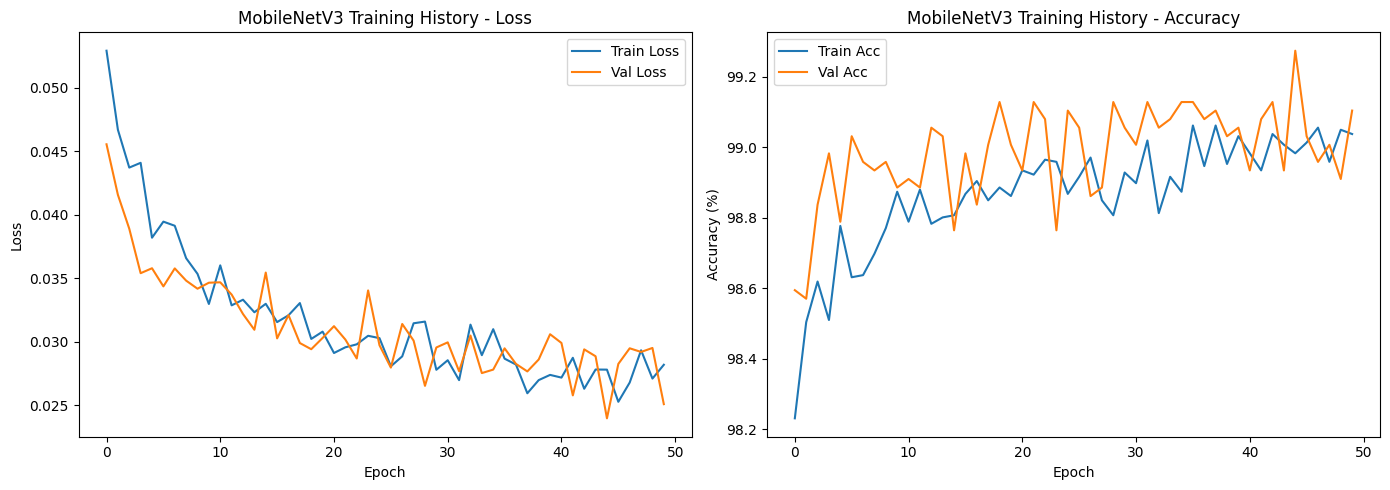

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(feature_extractor.parameters(), lr=0.001)
num_epochs = 50

feature_extractor, history = train_model(feature_extractor, train_loader, val_loader, criterion, optimizer, device, num_epochs, model_name="MobileNetV3")
plot_curves(history, title="MobileNetV3 Training History")


Sample Predictions:


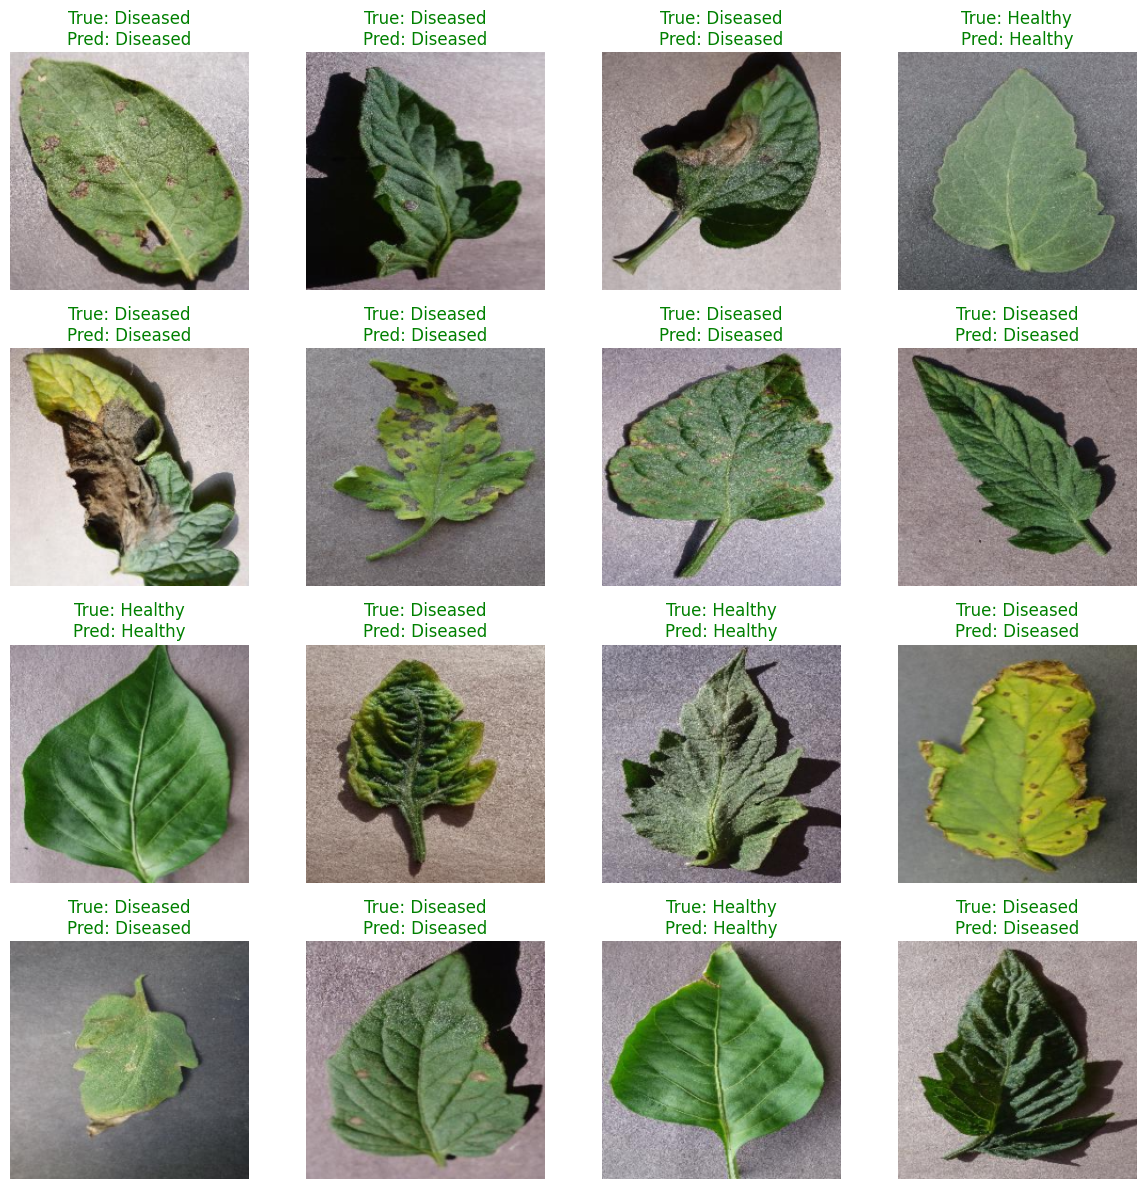

In [ ]:
print("\nSample Predictions:")
show_predictions(feature_extractor, val_loader, device, ["Diseased", "Healthy"], num_images=16)


In [3]:
from PIL import Image
import os

def predict_single_image(model, image_path, device, class_names=["Diseased", "Healthy"]):
    """
    Predict the class of a single image using the trained model.
    
    Args:
        model: Trained PyTorch model
        image_path: Path to the image file
        device: Device to run inference on
        class_names: List of class names
    """
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"Error: Image file '{image_path}' not found!")
        return
    
    try:
        # Load and preprocess the image
        image = Image.open(image_path).convert('RGB')
        
        # Apply test transforms
        transformed_image = test_transforms(image).unsqueeze(0)  # Add batch dimension
        
        # Move to device
        transformed_image = transformed_image.to(device)
        
        # Set model to evaluation mode
        model.eval()
        
        # Make prediction
        with torch.no_grad():
            output = model(transformed_image)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, predicted = probabilities.max(1)
        
        # Get prediction results
        predicted_class = class_names[predicted.item()]
        confidence_score = confidence.item() * 100
        
        # Display results
        print(f"\n{'='*50}")
        print(f"Image: {image_path}")
        print(f"Predicted Class: {predicted_class}")
        print(f"Confidence: {confidence_score:.2f}%")
        print(f"{'='*50}\n")
        
        # Display the image with prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        color = 'green' if predicted_class == "Healthy" else 'red'
        plt.title(f"Prediction: {predicted_class} ({confidence_score:.2f}%)", 
                 fontsize=14, color=color, weight='bold')
        plt.tight_layout()
        plt.show()
        
        return predicted_class, confidence_score
        
    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None, None

# Interactive prediction
print("="*60)
print("Plant Disease Detection - Single Image Prediction")
print("="*60)
image_path = input("\nEnter the path to the image file: ").strip()

# Remove quotes if user copied path with quotes
image_path = image_path.strip('"').strip("'")

predict_single_image(feature_extractor, image_path, device)

Plant Disease Detection - Single Image Prediction


NameError: name 'feature_extractor' is not defined